In [ ]:
# conda activate yolo_env

# Data Loading and Structuring

In [11]:
import os
import pandas as pd
import shutil
import random

In [2]:
# ==============================
# PATHS
# ==============================

csv_path = "Train.csv"
train_base_path = "."   # IMPORTANT (since Train folder is here)

output_base = "dataset/train"

images_output = os.path.join(output_base, "images")
labels_output = os.path.join(output_base, "labels")

os.makedirs(images_output, exist_ok=True)
os.makedirs(labels_output, exist_ok=True)


In [3]:
# ==============================
# LOAD DATA
# ==============================

df = pd.read_csv(csv_path)

print("Total rows:", len(df))

Total rows: 39209


**For Train Set**

In [ ]:
# ==============================
# PROCESS EACH ROW
# ==============================

for i, row in df.iterrows():

    # ---- Full image path ----
    img_path = os.path.join(train_base_path, row['Path'])

    if not os.path.exists(img_path):
        print(f"❌ Missing: {img_path}")
        continue

    # ---- Extract values ----
    class_id = int(row['ClassId'])

    x1 = float(row['Roi.X1'])
    y1 = float(row['Roi.Y1'])
    x2 = float(row['Roi.X2'])
    y2 = float(row['Roi.Y2'])

    w = float(row['Width'])
    h = float(row['Height'])

    # ---- Convert to YOLO format ----
    x_center = ((x1 + x2) / 2) / w
    y_center = ((y1 + y2) / 2) / h
    bbox_width = (x2 - x1) / w
    bbox_height = (y2 - y1) / h

    # ---- File names ----
    filename = os.path.basename(img_path)
    label_filename = filename.replace(".png", ".txt")

    label_path = os.path.join(labels_output, label_filename)

    # ---- Save label ----
    with open(label_path, "w") as f:
        f.write(f"{class_id} {x_center} {y_center} {bbox_width} {bbox_height}")

    # ---- Copy image ----
    new_img_path = os.path.join(images_output, filename)

    if not os.path.exists(new_img_path):  # avoid duplicate copy
        shutil.copy(img_path, new_img_path)
 
# ==============================
# DONE
# ==============================

print("✅ TRAIN DATA CONVERSION COMPLETE!")

✅ TRAIN DATA CONVERSION COMPLETE!


**For Test Set**

In [5]:
# ==============================
# PATHS
# ==============================

excel_path = "Test.csv"   # your test file
test_base_path = "."      # since Test folder is here

output_base = "dataset/test"

images_output = os.path.join(output_base, "images")
labels_output = os.path.join(output_base, "labels")

os.makedirs(images_output, exist_ok=True)
os.makedirs(labels_output, exist_ok=True)

In [6]:
# ==============================
# LOAD DATA
# ==============================

df = pd.read_csv(excel_path)

# Clean column names (IMPORTANT)
df.columns = df.columns.str.strip()

print("Total rows:", len(df))

Total rows: 12630


In [7]:
# ==============================
# PROCESS EACH ROW
# ==============================

for i, row in df.iterrows():

    # ---- Full image path ----
    img_path = os.path.join(test_base_path, row['Path'])

    if not os.path.exists(img_path):
        print(f"❌ Missing: {img_path}")
        continue

    # ---- Extract values ----
    class_id = int(row['ClassId'])

    x1 = float(row['Roi.X1'])
    y1 = float(row['Roi.Y1'])
    x2 = float(row['Roi.X2'])
    y2 = float(row['Roi.Y2'])

    w = float(row['Width'])
    h = float(row['Height'])

    # ---- Convert to YOLO format ----
    x_center = ((x1 + x2) / 2) / w
    y_center = ((y1 + y2) / 2) / h
    bbox_width = (x2 - x1) / w
    bbox_height = (y2 - y1) / h

    # ---- File names ----
    filename = os.path.basename(img_path)
    label_filename = filename.replace(".png", ".txt")

    label_path = os.path.join(labels_output, label_filename)

    # ---- Save label ----
    with open(label_path, "w") as f:
        f.write(f"{class_id} {x_center} {y_center} {bbox_width} {bbox_height}")

    # ---- Copy image ----
    new_img_path = os.path.join(images_output, filename)

    if not os.path.exists(new_img_path):
        shutil.copy(img_path, new_img_path)

# ==============================
# DONE
# ==============================

print("✅ TEST DATA CONVERSION COMPLETE!")

✅ TEST DATA CONVERSION COMPLETE!


In [8]:
# ==============================
# PATHS
# ==============================

train_images = "dataset/train/images"
train_labels = "dataset/train/labels"

val_images = "dataset/val/images"
val_labels = "dataset/val/labels"

os.makedirs(val_images, exist_ok=True)
os.makedirs(val_labels, exist_ok=True)

In [9]:
# ==============================
# GET ALL FILES
# ==============================

all_images = os.listdir(train_images)

print("Total images:", len(all_images))

Total images: 39209


In [12]:
# ==============================
# SHUFFLE & SPLIT
# ==============================

random.seed(42)  # for reproducibility
random.shuffle(all_images)

split_ratio = 0.2
split_index = int(len(all_images) * split_ratio)

val_files = all_images[:split_index]

print("Validation images:", len(val_files))

Validation images: 7841


In [13]:
# ==============================
# MOVE FILES
# ==============================

for file in val_files:

    # image paths
    img_src = os.path.join(train_images, file)
    img_dst = os.path.join(val_images, file)

    # label paths
    label_file = file.replace(".png", ".txt")
    label_src = os.path.join(train_labels, label_file)
    label_dst = os.path.join(val_labels, label_file)

    # move image
    shutil.move(img_src, img_dst)

    # move label
    if os.path.exists(label_src):
        shutil.move(label_src, label_dst)
    else:
        print("⚠️ Missing label:", label_file)

# ==============================
# DONE
# ==============================

print("✅ Validation split complete!")

✅ Validation split complete!


---

# YOLO V8 Implementation

In [1]:
import torch

print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
NVIDIA GeForce RTX 3070 Ti Laptop GPU


In [2]:
from ultralytics import YOLO

In [3]:
model = YOLO("yolov8n.pt")  # start with nano (fast)

In [4]:
# model.train(
#     data="data.yaml",
#     epochs=30,
#     imgsz=640,
#     batch=8,
#     workers=0,
#     device=0,
#     amp=True,
#     name="traffic_sign_model_1",

#     # reduce CPU load
#     degrees=0,
#     translate=0.05,
#     scale=0.3,
#     mosaic=0.5
# )

model.train(
    data="data.yaml",
    epochs=30,
    imgsz=512,
    batch=4,
    workers=1,
    device=0,
    amp=True,
    name="traffic_sign_model_1"
)

Ultralytics 8.4.39  Python-3.10.20 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3070 Ti Laptop GPU, 8192MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=512, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=traffic_sign_model_1, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=Tr

KeyboardInterrupt: 

In [ ]:
# conda activate yolo_env

In [1]:
from ultralytics import YOLO

model = YOLO("./runs/detect/traffic_sign_model_1/weights/last.pt")

In [2]:
model.train(resume=True)

Ultralytics 8.4.39  Python-3.10.20 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3070 Ti Laptop GPU, 8192MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=512, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=runs\detect\traffic_sign_model_1\weights\last.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=traffic_sign_model_1, nbs=64, nms=False, opset=None, optimize=

KeyboardInterrupt: 

In [2]:
model = YOLO("runs/detect/traffic_sign_model_1/weights/best.pt")

**TEST EVALUATION**

In [3]:
test_metrics = model.val(
    data="data.yaml",
    split="test"
)

print("Test mAP50:", test_metrics.box.map50)
print("Test mAP50-95:", test_metrics.box.map)
print("Precision:", test_metrics.box.mp)
print("Recall:", test_metrics.box.mr)

Ultralytics 8.4.39  Python-3.10.20 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3070 Ti Laptop GPU, 8192MiB)
Model summary (fused): 73 layers, 3,014,033 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access  (ping: 0.30.1 ms, read: 2.93.0 MB/s, size: 12.2 KB)
val: Scanning E:\Datamites\Internship phase 2\4. Traffic Sign Detection\Source code\dataset\test\labels... 12630 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 12630/12630 383.4it/s 32.9s<0.0s
val: New cache created: E:\Datamites\Internship phase 2\4. Traffic Sign Detection\Source code\dataset\test\labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 790/790 12.0it/s 1:06<0.1ss
                   all      12630      12630      0.909      0.933      0.935      0.886
                     0         60         60      0.989          1      0.995      0.947
                     1        720        720      0.984      0.994      0.994      0.949
              

> The YOLOv8 model achieved strong performance with an mAP50 of 0.935 and mAP50-95 of 0.886 on the test dataset. The model demonstrates high precision and recall, indicating reliable detection and minimal missed objects. Most classes achieved near-perfect detection accuracy; however, performance drops were observed in underrepresented classes due to data imbalance. Overall, the model is robust, efficient, and suitable for real-time traffic sign detection applications.

In [4]:
model.predict(
    source="dataset/test/images",
    save=True,
    conf=0.25
)


WARNING 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

image 1/12630 e:\Datamites\Internship phase 2\4. Traffic Sign Detection\Source code\dataset\test\images\00000.png: 512x512 1 16, 28.9ms
image 2/12630 e:\Datamites\Internship phase 2\4. Traffic Sign Detection\Source code\dataset\test\images\00001.png: 512x480 1 1, 38.6ms
image 3/12630 e:\Datamites\Internship phase 2\4. Traffic Sign Detection\Source code\dataset\test\images\00002.png: 512x480 1 38, 8.6ms
image 4/12630 e:\Datamites\Internship phase 2\4. Traffi

[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: '0', 1: '1', 2: '2', 3: '3', 4: '4', 5: '5', 6: '6', 7: '7', 8: '8', 9: '9', 10: '10', 11: '11', 12: '12', 13: '13', 14: '14', 15: '15', 16: '16', 17: '17', 18: '18', 19: '19', 20: '20', 21: '21', 22: '22', 23: '23', 24: '24', 25: '25', 26: '26', 27: '27', 28: '28', 29: '29', 30: '30', 31: '31', 32: '32', 33: '33', 34: '34', 35: '35', 36: '36', 37: '37', 38: '38', 39: '39', 40: '40', 41: '41', 42: '42'}
 obb: None
 orig_img: array([[[173, 138, 115],
         [172, 138, 116],
         [169, 137, 116],
         ...,
         [135, 110,  86],
         [126, 101,  80],
         [105,  82,  63]],
 
        [[178, 143, 118],
         [177, 140, 116],
         [174, 138, 115],
         ...,
         [171, 142, 120],
         [167, 139, 119],
         [166, 136, 117]],
 
        [[177, 143, 116],
         [174, 139, 113],
         [174, 140, 11

In [9]:
%matplotlib inline

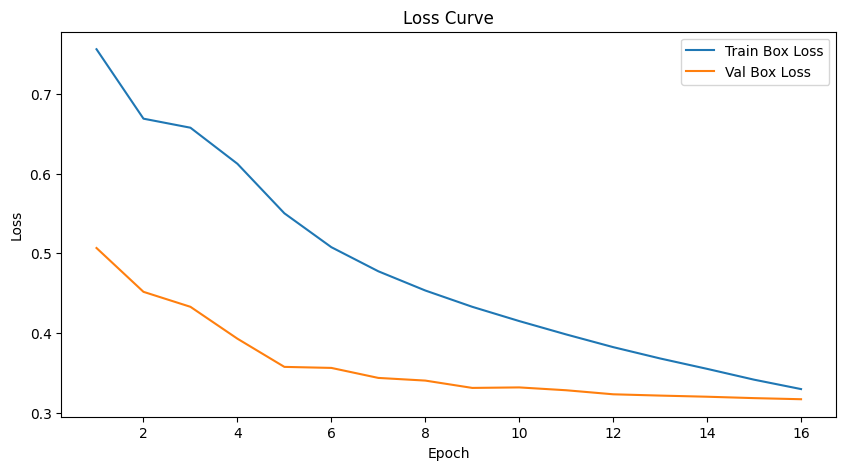

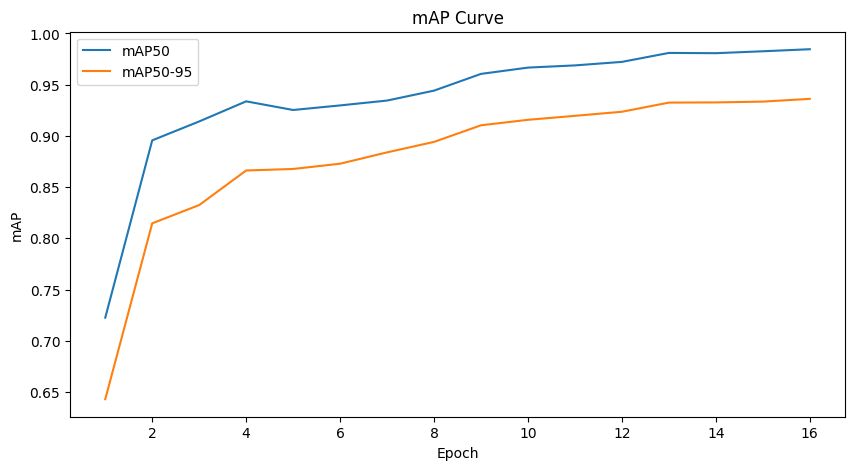

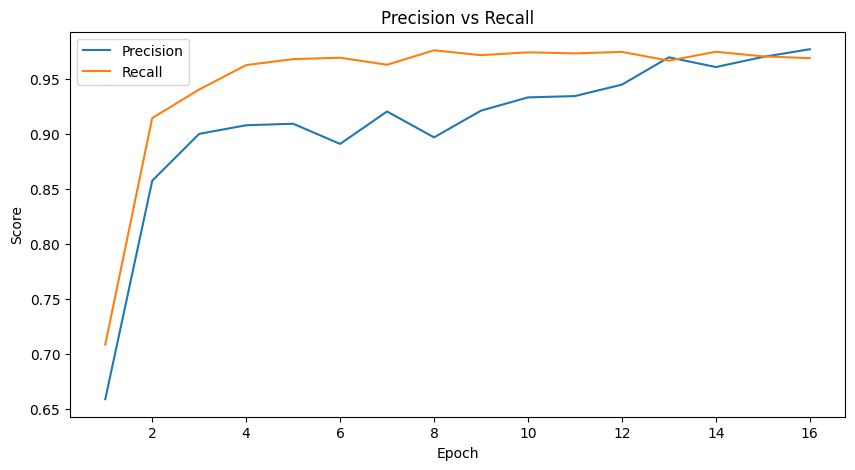

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

# Load CSV
df = pd.read_csv("runs/detect/traffic_sign_model_1/results.csv")

# Plot losses
plt.figure(figsize=(10,5))
plt.plot(df['epoch'], df['train/box_loss'], label='Train Box Loss')
plt.plot(df['epoch'], df['val/box_loss'], label='Val Box Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.legend()
plt.show()

# Plot mAP
plt.figure(figsize=(10,5))
plt.plot(df['epoch'], df['metrics/mAP50(B)'], label='mAP50')
plt.plot(df['epoch'], df['metrics/mAP50-95(B)'], label='mAP50-95')
plt.xlabel("Epoch")
plt.ylabel("mAP")
plt.title("mAP Curve")
plt.legend()
plt.show()

# Plot Precision & Recall
plt.figure(figsize=(10,5))
plt.plot(df['epoch'], df['metrics/precision(B)'], label='Precision')
plt.plot(df['epoch'], df['metrics/recall(B)'], label='Recall')
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("Precision vs Recall")
plt.legend()
plt.show()

> The training process demonstrates stable convergence with a consistent decrease in loss values and a steady increase in mAP, precision, and recall. The absence of divergence between training and validation loss indicates that the model does not suffer from overfitting. The mAP curves show rapid learning in early epochs followed by saturation, suggesting that the model has effectively learned the dataset. The precision and recall curves indicate a well-balanced model with high detection accuracy and minimal false predictions.

# 📄 **PROJECT REPORT**

## Traffic Sign Detection using YOLOv8

---

# 🔹 1. Problem Statement

Traffic sign detection is a critical component of intelligent transportation systems and autonomous driving. Accurate detection of traffic signs helps improve road safety by enabling systems to recognize and respond to road conditions effectively.

The objective of this project is to develop a deep learning-based model that can accurately detect and classify traffic signs from images using object detection techniques.

---

# 🔹 2. Dataset Description

The dataset used for this project was provided by Rubixe during internship.

### 📁 Dataset Structure:

* **Train Folder** → Images categorized into 43 classes (0–42)
* **Test Folder** → 12,630 images
* **Annotations** → Provided via CSV files containing:

  * Bounding box coordinates (ROI)
  * Class labels
  * Image paths

---

### 🔧 Preprocessing Steps:

* Converted CSV annotations → YOLO format (`.txt`)
* Normalized bounding box coordinates:

  ```text
  x_center, y_center, width, height
  ```
* Organized dataset into:

  ```
  dataset/
      train/
          images/
          labels/
      val/
          images/
          labels/
      test/
          images/
          labels/
  ```

---

# 🔹 3. Methodology

### 📌 Model Used:

We used **Ultralytics YOLOv8** for object detection.

---

### 📌 Why YOLOv8?

* Real-time detection capability
* High accuracy
* Efficient for small objects (traffic signs)
* Easy to train and deploy

---

### ⚙️ Training Configuration:

```text
Model        : YOLOv8n (Nano)
Epochs       : 16
Image Size   : 512
Batch Size   : 4
Optimizer    : SGD (default)
Device       : NVIDIA RTX 3070 Ti GPU
```

---

### 🧠 Training Strategy:

* Training performed with early stopping consideration
* Model checkpointing used (`best.pt`)
* GPU acceleration utilized
* Overheating managed using controlled training cycles

---

# 🔹 4. Results

### 📊 Final Test Performance:

```text
mAP50      : 0.935
mAP50-95   : 0.886
Precision  : 0.909
Recall     : 0.933
```

---

### 📈 Observations from Graphs:

#### 📉 Loss Curve

* Training and validation loss decreased steadily
* No divergence observed → no overfitting

#### 📈 mAP Curve

* Rapid increase in early epochs
* Plateau after epoch ~12 → convergence achieved

#### ⚖️ Precision vs Recall

* Both metrics stabilized above 0.95
* Indicates balanced and reliable predictions

---

# 🔹 5. Analysis

### ✅ Strengths:

* High detection accuracy across most classes
* Strong generalization on test dataset
* Balanced precision and recall
* Fast inference (~real-time capable)

---

### 🔍 Class-wise Insight:

* Most classes achieved near-perfect detection (mAP ≈ 0.99)
* Few classes showed lower performance due to:

  * Limited training samples
  * Visual similarity between signs

---

### 🖼️ Prediction Analysis:

* Bounding boxes are tightly fitted
* High confidence detections observed
* Model performs well even on small-sized images

---

# 🔹 6. Limitations

* Class imbalance in dataset
* Some traffic signs have very few samples
* Difficulty distinguishing visually similar signs
* Small image resolution affects fine-grained detection

---

# 🔹 7. Future Improvements

* Increase dataset size for low-performing classes
* Use larger model (YOLOv8s / YOLOv8m)
* Increase input image resolution (640 or 800)
* Apply advanced data augmentation
* Use class balancing techniques

---

# 🔹 8. Conclusion

This project successfully implemented a traffic sign detection system using YOLOv8. The model achieved high accuracy and demonstrated strong performance across most classes. The results indicate that the model is reliable, efficient, and suitable for real-time applications such as autonomous driving and intelligent traffic systems.

---

# Summary

> The proposed YOLOv8-based model achieved high detection accuracy with an mAP50 of 0.935, demonstrating strong capability in both detection and localization of traffic signs, making it suitable for real-world deployment scenarios.

---